# Ripple Testinng

In [1]:


# Loading/Import related packages
import sys
import os

#Usual suspects
import pandas as pd
import numpy as np
import json
import pickle as pkl
import matplotlib.pyplot as plt

#Extras for plotting
from matplotlib.patches import Patch

#Extra for typing
from collections import defaultdict

os.chdir(r"C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\Ripple")
# # Needed to point the importer to the src folder
# sys.path.insert(0,r"C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\Ripple")

In [2]:
from src.muniverse.algorithms.core import bandpass_signals, notch_signals
from ripple_analysis_functions import get_task_data, remove_spikes, remove_spikes_dict, calc_PSD, emg_inspect, generate_psd_fig, plot_emg_with_psd


In [3]:
# This task used 3 tasks, each with 8 repitions
n_reps = 8
n_tasks = 3
movement_names = ['fist', 'fast_tripod', 'fast_finger_ext']

samp_freq = 2000
n_channels = 32

In [4]:
REPO_DIR  = os.path.abspath(os.getcwd())
INPUT_DIR = os.path.join(REPO_DIR, 'data')
OUTPUT_DIR = os.path.join(REPO_DIR, 'results')

combined_data_1_path = os.path.join(INPUT_DIR, 'emg_recording_giuan_tewst_20260826_122524.pkl')
s1_folder = os.path.join(INPUT_DIR, 'emg_recording_giuan_tewst_20260826_122524_divided')
s2_folder = os.path.join(INPUT_DIR, 'emg_recording_giuan_tewst2_20260826_135844_divided')

result_pandas = pd.read_pickle(combined_data_1_path)
print(result_pandas.keys())
print(result_pandas['trial_metadata']['items'])


dict_keys(['data', 'srate', 'n_channels', 'filtered', 'pre_trigger_seconds', 'timestamp', 'stream_type', 'trial_metadata', 'session_timeline'])
[{'index': 0, 'model': 'fist.glb', 'animation': 0, 'repetitions': 8}, {'index': 1, 'model': 'fasttripodpinch.glb', 'animation': 0, 'repetitions': 8}, {'index': 2, 'model': 'fastfingerext.glb', 'animation': 0, 'repetitions': 8}]


### Signal

##### Session 1

In [5]:
s1_full = get_task_data(s1_folder, 8, movement_names, samp_freq, win = None)
s1_fist = s1_full['fist']
s1_ft = s1_full['fast_tripod']
s1_ffe = s1_full['fast_finger_ext']

s1_fist_rest = s1_fist['rest']
s1_fist_mr_combined = s1_fist['m_r_combined']['emg']



# isolating just middle 4 seconds, should be isometrical hold only. No start of movement.
"""
Maybe need to change window to cut off first N seconds because that is when the movement is initiated.
Isometrical hold for entire period, participant releases movement after movement duration period (ie first N seconds of rest)
"""
s1_iso4 = get_task_data(s1_folder, 8, movement_names, samp_freq, win = 4)
s1_fist_iso4 = s1_iso4['fist']['movement']['emg_combined']
s1_ft_iso4 = s1_iso4['fast_tripod']['movement']['emg_combined']
s1_ffe_iso4 = s1_iso4['fast_finger_ext']['movement']['emg_combined']

##### Session 2

In [6]:
s2_full = get_task_data(s2_folder, 8, movement_names, samp_freq, win = None)
s2_fist = s2_full['fist']['movement']['emg_combined']
s2_ft = s2_full['fast_tripod']['movement']['emg_combined']
s2_ffe = s2_full['fast_finger_ext']['movement']['emg_combined']

s2_fist_rest = s2_full['fist']['rest']['emg_combined']


In [7]:
# A basic plotting function to visualize the emg is something like this
# Requires sampling frequency or fs, to map between emg samples and time
# fs is usually 2048 Hz, unless specified 

def plot_emg_with_movement(emg_array, poses, durations, fs, channel=(0, 0), ax=None):

    """
    Plot a single EMG channel, with a coloured patch behind each pose.

    Parameters:
    - emg_array: np.ndarray, either n_rows x n_cols x n_samples (grid) or n_channels x n_samples (flat).
    - poses: sequence of str, the name of the pose performed in each block, in order.
    - durations: sequence of float, the duration in seconds of each pose, same order as poses.
    - fs: float, the sampling frequency of the EMG in Hz.
    - channel: (row, col) for a grid array, or an int for a flat one.
    - ax: optional matplotlib axis, so this can be reused inside bigger figures.

    Returns:
    - ax: the axis the signal was drawn on.
    """

    # We usually show the trace of a single channel for visualization purposes,
    # but we might also use the RMS if the movement is not clearly visible above noise
    emg_array = np.asarray(emg_array)

    if emg_array.ndim == 3:
        row, col = channel
        signal = emg_array[row, col, :]
        ch_label = f"channel ({row}, {col})"
    else:
        ch = channel if isinstance(channel, int) else channel[0]
        signal = emg_array[ch, :]
        ch_label = f"channel {ch}"

    # The signal is stored sample by sample, so we build the time axis ourselves
    t = np.arange(signal.size) / fs

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))

    # One colour per unique pose name: if the same pose is repeated later in the recording,
    # it keeps the same colour (dict.fromkeys preserves the order of first appearance)
    unique_poses = list(dict.fromkeys(poses))
    cmap = plt.get_cmap('tab10' if len(unique_poses) <= 10 else 'tab20')
    colors = {pose: cmap(i % cmap.N) for i, pose in enumerate(unique_poses)}

    # The poses are performed one after the other, so a pose starts where the previous ones ended:
    # the cumulative sum of the durations gives us the boundaries of every block, in seconds
    edges = np.concatenate(([0.0], np.cumsum(durations)))

    for pose, start, end in zip(poses, edges[:-1], edges[1:]):
        # Clipped to the end of the signal, in case the durations add up to more than what was recorded
        ax.axvspan(min(start, t[-1]), min(end, t[-1]), color=colors[pose], alpha=0.25, lw=0)

    ax.plot(t, signal, color='0.15', lw=0.4)

    ax.set_xlim(0, t[-1])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'EMG - {ch_label}')
    ax.set_title('EMG signal with intended poses')

    # A patch legend, one entry per pose, drawn with the same alpha as the patches
    handles = [Patch(facecolor=colors[pose], alpha=0.25, label=pose) for pose in unique_poses]
    ax.legend(handles=handles, fontsize=8, loc='upper right', ncol=min(len(handles), 4))

    return ax

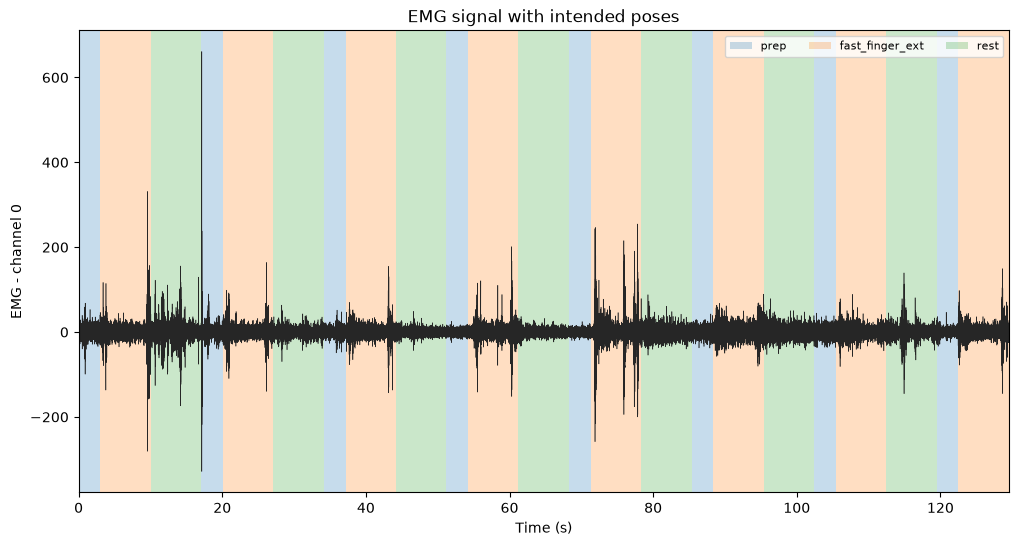

In [10]:
plot_emg_with_movement(s1_ffe['m_r_combined']['emg'], 
                       s1_ffe['m_r_combined']['poses'], 
                       s1_ffe['m_r_combined']['duration'], 
                       fs=samp_freq)
plt.show()

### Preprocessing

##### Bandpass + Notch Filters

In [9]:
filt_emg_sig = s1_fist.copy()
# Apply a notch filter
sig = notch_signals(
    emg_data = filt_emg_sig, 
    fsamp=samp_freq, 
    nfreq=50, 
    dfreq=1,
    order=2,
    n_harmonics = 10
)
# Apply a bandpass filter
sig = bandpass_signals(
    emg_data=sig,
    fsamp=samp_freq,
    high_pass=20,
    low_pass=500,
    order=2
)


filtered_emg_noise = s1_fist_rest.copy()
# Apply a notch filter
noise = notch_signals(
    emg_data=filtered_emg_noise,
    fsamp=samp_freq,
    nfreq=50,
    dfreq=1,
    order=2,
    n_harmonics = 10
)
# Apply a bandpass filter
noise = bandpass_signals(
    emg_data=noise,
    fsamp=samp_freq,
    high_pass=20,
    low_pass=500,
    order=2
)

# Calculate the power spectral density (PSD)
Pn, fn = calc_PSD(noise)
Ps, fs = calc_PSD(sig)

# Calculate the SNR
p_sig = np.mean(sig**2)
p_noise = np.mean(noise**2)
snr = 10 * np.log10(p_sig / p_noise)


plot_emg_with_psd(
    sig=sig,
    noise=noise,
    fn = fn,
    fs = fs,
    pn = Pn,
    ps = Ps,
    fsamp=samp_freq,
    save_path="results/s1_fist_filter_harm10.png"
)


IndexError: tuple index out of range

In [ ]:
s1_clean = remove_spikes_dict(s1_full, threshold_std=3)
s1_rest_emg_clean = remove_spikes_dict(s1_rest_emg, threshold_std=3)

s2_clean = remove_spikes_dict(s2_full, threshold_std=3)
s2_rest_clean = remove_spikes_dict(s2_rest_emg, threshold_std=3)

KeyError: 'combined_emg_reps'

In [ ]:
s1_inspect = emg_inspect(s1_full, s1_rest_emg, samp_freq)
s1_clean_inspect = emg_inspect(s1_clean, s1_rest_emg_clean, samp_freq, emg_name_key='combined_emg_reps_clean')


In [ ]:
all_psds_noise = []

for rep in s1_rest_emg['rest']['emg_reps']:
    Pn, fn = calc_PSD(
        rep.to_numpy(),
        fsamp=samp_freq,
        nperseg=samp_freq,
        noverlap=samp_freq // 2
    )
    all_psds_noise.append(Pn)

P_mean = np.mean(all_psds_noise, axis=0)

all_psds_sig = []

for rep in s1_full['fist']['emg_reps']:
    Ps, fs = calc_PSD(
        rep.to_numpy(),
        fsamp=samp_freq,
        nperseg=samp_freq,
        noverlap=samp_freq // 2
    )
    all_psds_sig.append(Ps)

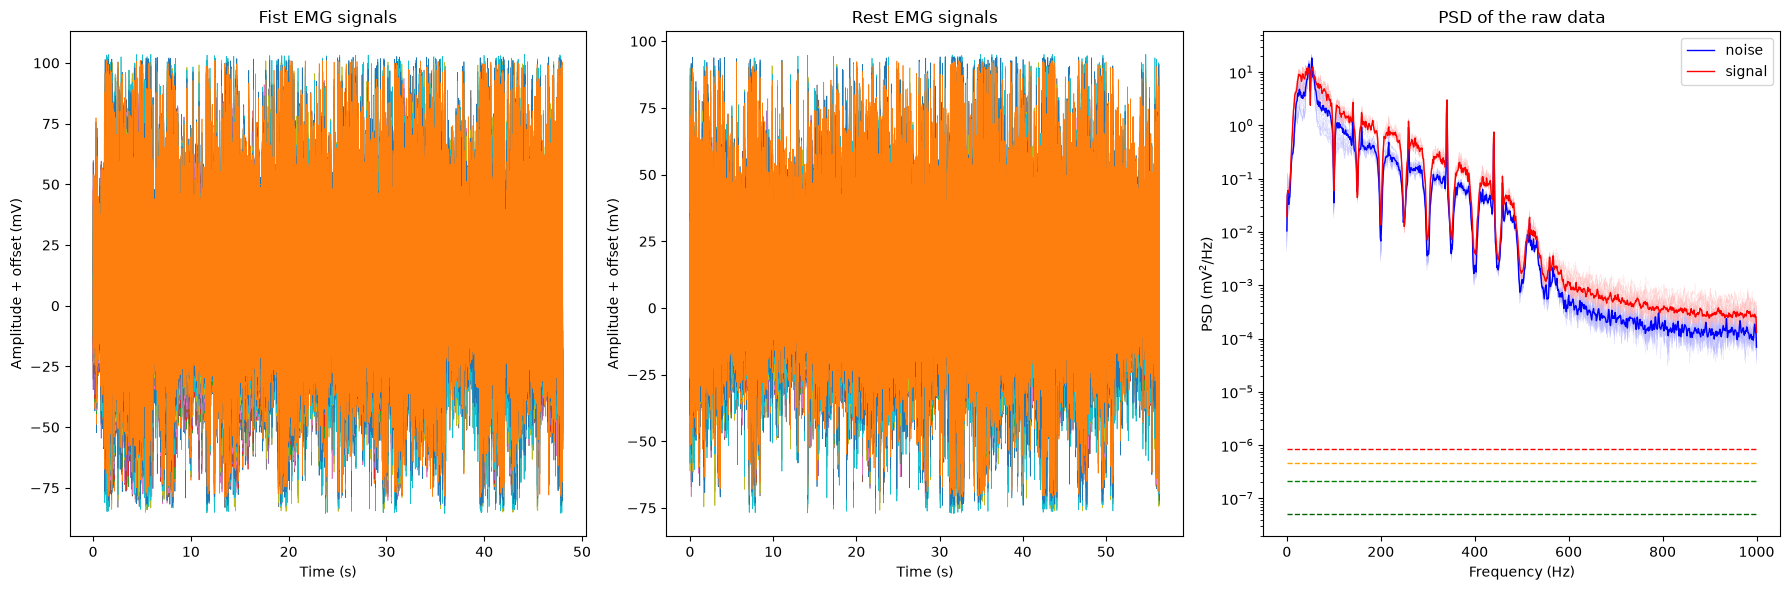

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Fist EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'Rest EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'PSD of the raw data'}, xlabel='Frequency (Hz)', ylabel='PSD (mV$^2$/Hz)'>],
       dtype=object))

In [ ]:
s1_fist_clean = s1_clean['fist']['combined_emg_reps_clean']
s1_rest_emg_clean = s1_rest_emg_clean['rest']['combined_emg_reps_clean']

# generate_psd_fig(
#     emg_data=s1_fist_clean,
#     fn = s1_clean_inspect['rest']['psd'][1],
#     fs = s1_clean_inspect['fist']['psd'][1],
#     pn = s1_clean_inspect['rest']['psd'][0],
#     ps = s1_clean_inspect['fist']['psd'][0],
#     samp_freq=samp_freq,
#     save_path="results/s1_fist_clean_psd.png"
# )

plot_emg_with_psd(
    sig=s1_fist_clean,
    noise=s1_rest_emg_clean,
    fn = s1_clean_inspect['rest']['psd'][1],
    fs = s1_clean_inspect['fist']['psd'][1],
    pn = s1_clean_inspect['rest']['psd'][0],
    ps = s1_clean_inspect['fist']['psd'][0],
    fsamp=samp_freq,
    save_path="results/s1_fist_cleaned_psd.png"
)

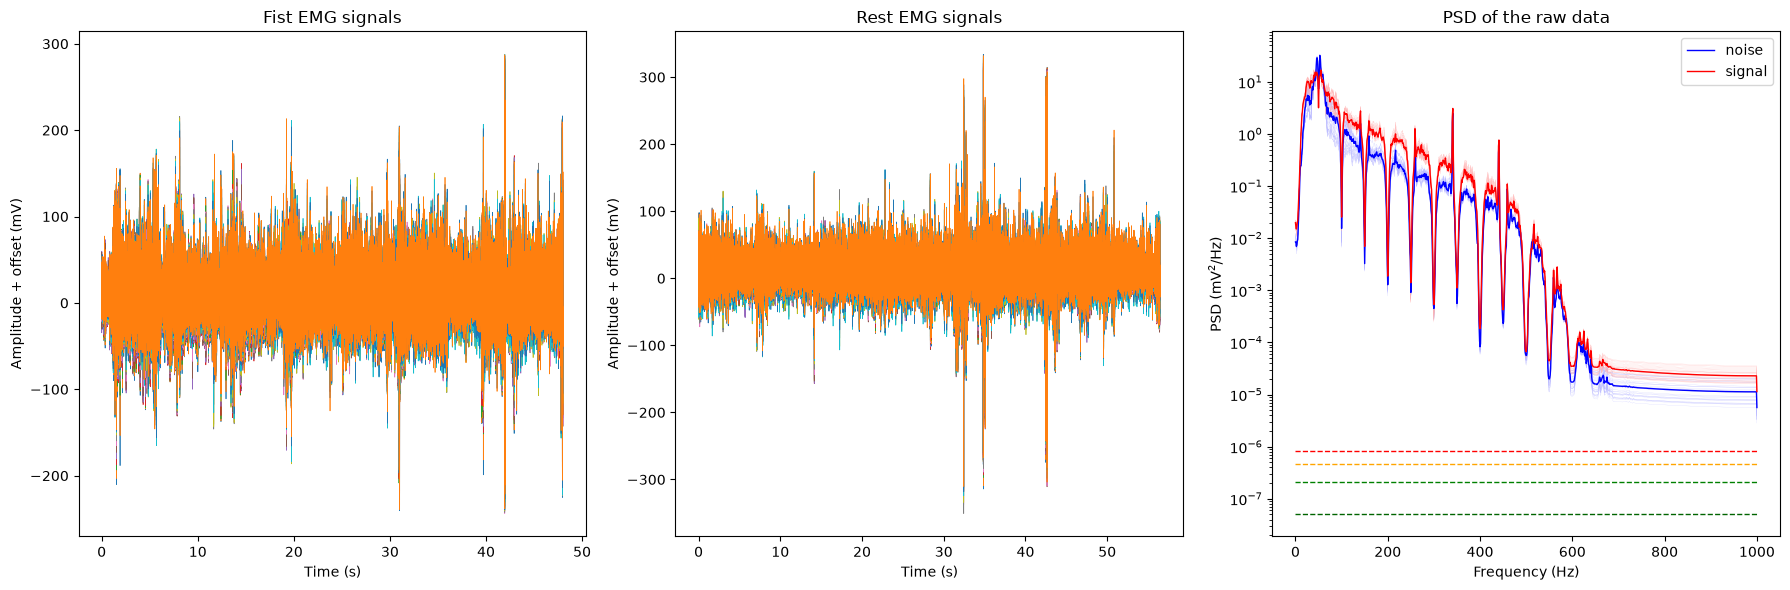

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Fist EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'Rest EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'PSD of the raw data'}, xlabel='Frequency (Hz)', ylabel='PSD (mV$^2$/Hz)'>],
       dtype=object))

In [ ]:
s1_fist = s1_full['fist']['combined_emg_reps']
s1_rest_emg = s1_rest_emg['rest']['combined_emg_reps']

# generate_psd_fig(
#     emg_data=s1_fist,
#     fn = s1_fist_fn,
#     fs = s1_fist_fs,
#     pn = s1_fist_pn,
#     ps = s1_fist_ps,
#     samp_freq=samp_freq,
#     save_path="results/s1_fist_psd.png"
# )
plot_emg_with_psd(
    sig=s1_fist,
    noise=s1_rest_emg,
    fn = s1_inspect['rest']['psd'][1],
    fs = s1_inspect['fist']['psd'][1],
    pn = s1_inspect['rest']['psd'][0],
    ps = s1_inspect['fist']['psd'][0],
    fsamp=samp_freq,
    save_path="results/s1_fist_psd.png"
)